In [1]:
# Imports
import matplotlib.pyplot as plt
from astropy import units as u
from astropy.io import fits
from astropy.wcs import WCS
from astropy.visualization.wcsaxes import WCSAxes
from astropy.coordinates import SkyCoord, FK5
from spectral_cube import SpectralCube
from velocity_tools import extract_streamline, gradient_descent, stream_lines_grad
from velocity_tools import stream_lines # won't use this directly, but needed to compare with stream_lines_grad
import os
import numpy as np
import jax.numpy as jnp
from jax import value_and_grad

import warnings
warnings.filterwarnings('ignore', message='.*PV2_1.*')
warnings.filterwarnings('ignore', message='.*PV2_2.*')
warnings.filterwarnings('ignore', message='.*TIMESYS.*')

# Settings
hltau_c= SkyCoord("4h31m38.43s", "+18d13m57.19s", frame='fk5')
hltau_ref = hltau_c.skyoffset_frame()
distance = 147 #parsecs
cubefile = 'test_data/HLTAU_HCOp32.fits'
file_TdV = 'test_data/HLTAU_HCOp32_TdV.fits'


/Users/laurenmason/.pyenv/versions/.vtenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### TODO: Extract streamer cube from original cube
### Prepare the 1D streamer emission from the cube

In [2]:
# get the spectralcube object from the data using spectral-cube
hdu = fits.open(cubefile)[0]
cube = SpectralCube.read(hdu).with_spectral_unit(u.km/u.s, rest_value=hdu.header['RESTFRQ']*u.Hz)

# if the mom0 map isn't made yet, make it
if not os.path.exists(file_TdV):
    cube_mom0 = cube.moment0()
    hdu_mom0 = cube_mom0.hdu
    hdu_mom0.writeto(file_TdV)
print("Loaded cube with shape:", cube.shape)

# TODO: this streamer extraction should be replaced with clustering-based streamer extraction

# extract the subcube with the streamer (we got this from the tipsy tutorial, no need to plot)
## Limits for extracting subcube with streamer
vmin = 7    # Min. vel. of streamer
vmax = 10
xmin = -3   # Min R.A. offset (arcsec) to consider for streamer
xmax = -1
ymin = -3   # Min. Decl. offset (arcsec) to consider for streamer
ymax = 0.5
rms_thresh = 4  # sigma threshold for streamer

# extract the streamer subcube
info_header = cube.header  # header of the cube, contains required information
x_conv_fac = 1/60/60/info_header['CDELT1']
xmin_p = int((xmin*x_conv_fac)+info_header['CRPIX1'])
xmax_p = int((xmax*x_conv_fac)+info_header['CRPIX1'])
y_conv_fac = 1/60/60/info_header['CDELT2']
ymin_p = int((ymin*y_conv_fac)+info_header['CRPIX2'])
ymax_p = int((ymax*y_conv_fac)+info_header['CRPIX2'])
vunit = cube.spectral_axis.unit
## Note: a check can be added to see if requested limits are within the limits of the cube itself

streamer_cubev = cube.spectral_slab(vmin*vunit,vmax*vunit)    # Selecting velocities
streamer_cubevc = streamer_cubev[:,min(ymin_p,ymax_p):max(ymin_p,ymax_p)   
                    ,min(xmin_p,xmax_p):max(xmin_p,xmax_p)]   # Selecting pixels
#     print(min(ymin_p,ymax_p),max(ymin_p,ymax_p),min(xmin_p,xmax_p),max(xmin_p,xmax_p)) 
streamer_cube = streamer_cubevc.with_mask(streamer_cubevc > rms_thresh*streamer_cubevc.mad_std())  # Removing low flux values 


Loaded cube with shape: (500, 401, 401)


In [3]:

# Extract 1D streamline from the data cube
pc_coords, pc_means, pc_stds = extract_streamline.reduce_to_1D(streamer_cube, n_elements=10)

# Prepare data for gradient descent
ra_data = pc_means[0] # offsets in arcsec
dec_data = pc_means[1] # offsets in arcsec
v_data = pc_means[2]   # velocities in km/s (rel to vlsr)

ra_sigma = pc_stds[0]
dec_sigma = pc_stds[1]
v_sigma = pc_stds[2]


data = (ra_data, dec_data, v_data)
uncertainties = (ra_sigma, dec_sigma, v_sigma)

Starting reduction
Created coordinate arrays
Got point cloud with 14974 points
Partition boundaries for projected distance metric: [1.031 1.122 1.176 1.234 1.3   1.383 1.48  1.602 1.732 1.898 3.251]


Text(0.5, 1.0, 'Extracted 1D Streamer emission')

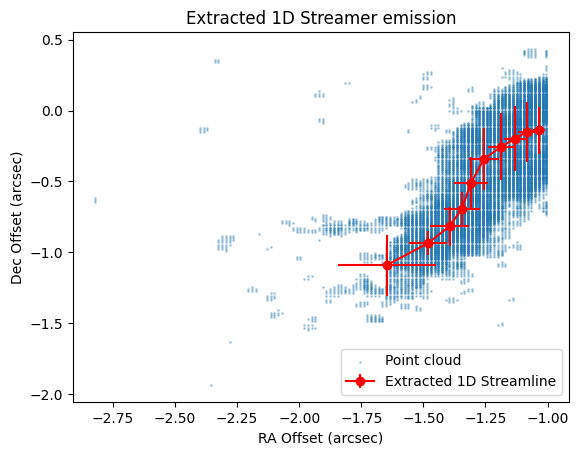

In [4]:
# plot it
import matplotlib.pyplot as plt
# plot the observed data points as a scatter
plt.scatter(pc_coords[0], pc_coords[1], s=1, alpha=0.3, label='Point cloud')
# plot the extracted 1D streamline with error bars
plt.errorbar(ra_data, dec_data, xerr=ra_sigma, yerr=dec_sigma, fmt='o-', label='Extracted 1D Streamline', color='red')
plt.xlabel('RA Offset (arcsec)')
plt.ylabel('Dec Offset (arcsec)')
plt.legend()
plt.title('Extracted 1D Streamer emission')

### Initial guess at parameters, and plot

The plot is so you can refine your initial parameters a bit. The comparison between stream_lines and stream_lines_grad is just a sanity check.

Running stream_lines...
rc=1.9220526946751497 AU
10.0 AU
tolerance  3.5903488968000007e-07
Running stream_lines_grad...
Plotting results...


/var/folders/cf/gbp0295d3dgg0vcn3fvpmybw0000gr/T/ipykernel_50914/346457170.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


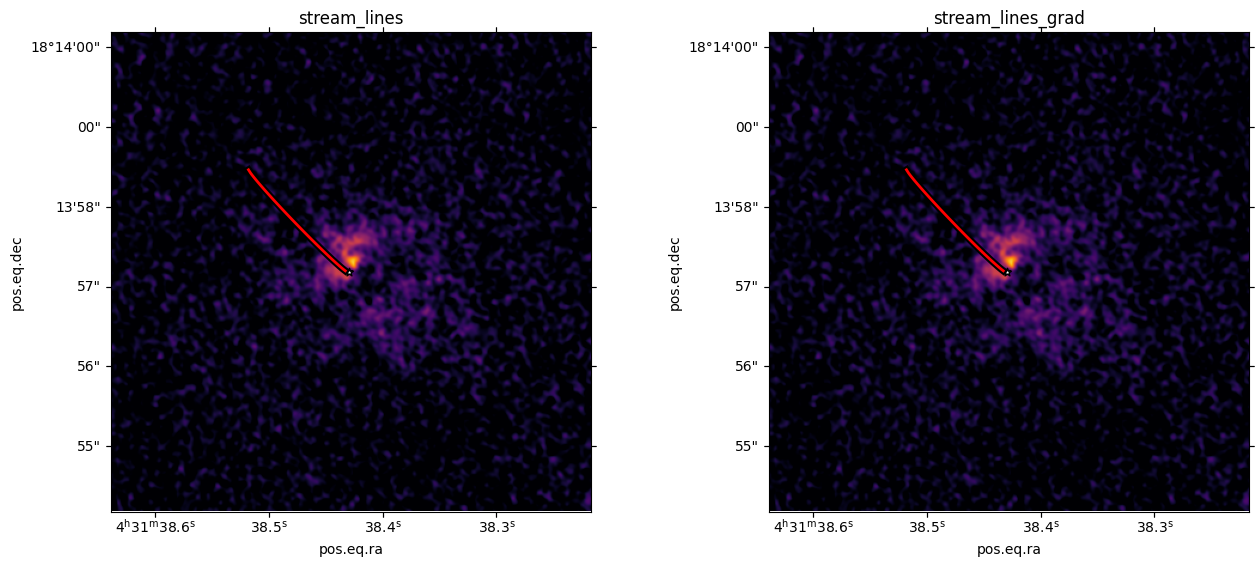

[1.2542033  1.2276351  1.2089223  1.1925936  1.1765065  1.1610326
 1.1457958  1.1308782  1.1161046  1.1015416  1.0870891  1.0727627
 1.0585952  1.0444481  1.0304756  1.0164905  1.002694   0.98887455
 0.9751644  0.96149343 0.94787014 0.934343   0.9208266  0.90737253
 0.89393926 0.8805954  0.86726266 0.8537388  0.84068096 0.82735604
 0.81426567 0.80109185 0.78802246 0.7749328  0.76190495 0.74891895
 0.7359331  0.72300947 0.7101009  0.697218   0.6843686  0.6715579
 0.65877455 0.6459968  0.63328505 0.6205735  0.6076128  0.5952514
 0.5823427  0.5700347  0.55719906 0.54491204 0.53217816 0.51989627
 0.5072713  0.4949904  0.48246968 0.4702024  0.45777488 0.44552305
 0.43277454 0.4211104  0.40825    0.3967024  0.38384134 0.37236777
 0.3596697  0.34801996 0.33627778 0.3232229  0.31229997 0.2993357
 0.28831893 0.27592745 0.26439208 0.252787   0.24071033 0.22956462
 0.21745066 0.20631684 0.19432214 0.18327473 0.17140761 0.16046008
 0.1491491  0.13790748 0.12674148 0.11565939 0.10466748 0.09377718


In [5]:
# Initial guesses at params
r0 = 1000*u.au
theta0 = 130.*u.deg
phi0 = 70.*u.deg
omega0 = 4e-13/u.s
v_r0 = 0*u.km/u.s
# params we set
Mstar = 2.1*u.Msun
inc = -43*u.deg
PA_ang = 130*u.deg
v_lsr = 7.14*u.km/u.s


# Run the forward model with initial params - using stream_lines
# x = RA offset (au), y = velocity (km/s), z = Dec offset (au)
print("Running stream_lines...")
(x1, y1, z1), (vx1, vy1, vz1) = stream_lines.xyz_stream(
                mass=Mstar, r0=r0, theta0=theta0, phi0=phi0,
                omega=omega0, v_r0=v_r0, inc=inc, pa=PA_ang,
                rmin=0.5e2*u.au, deltar=10*u.au) #<- decrease deltar for more accurate streamer calculation
dra_stream1 = -x1.value / distance * u.arcsec 
ddec_stream1 = z1.value / distance * u.arcsec
fil1 = SkyCoord(dra_stream1, ddec_stream1, frame=hltau_ref).transform_to(FK5)

# Run the forward model with initial params - using stream_lines_grad
# convert angles to radians, and strip units from all quantities
r0 = r0.to(u.au).value
theta0 = theta0.to(u.rad).value
phi0 = phi0.to(u.rad).value
omega0 = omega0.to(1/u.s).value
v_r0 = v_r0.to(u.km/u.s).value
inc = inc.to(u.rad).value
PA_ang = PA_ang.to(u.rad).value
Mstar = Mstar.to(u.Msun).value
v_lsr = v_lsr.to(u.km/u.s).value
# x = RA offset (au), y = velocity (km/s), z = Dec offset (au)
print("Running stream_lines_grad...")
(x2, y2, z2), (vx2, vy2, vz2) = stream_lines_grad.xyz_stream(
                mass=Mstar, r0=r0, theta0=theta0, phi0=phi0,
                omega=omega0, v_r0=v_r0, inc=inc, pa=PA_ang,
                rmin=50, deltar=10) #<- decrease deltar for more accurate streamer calculation
dra_stream2 = -x2._value / distance * u.arcsec # note the _value to get raw number for stream_lines_grad
ddec_stream2 = z2._value / distance * u.arcsec
fil2 = SkyCoord(dra_stream2, ddec_stream2, frame=hltau_ref).transform_to(FK5)

print("Plotting results...")
# Load the moment 0 data
hdu = fits.open(file_TdV)[0]
wcs_TdV = WCS(hdu.header)

# Create figure with two subplots side by side
plt.close('all')
fig = plt.figure(figsize=(14, 6))

# Left subplot - stream_lines
ax1 = WCSAxes(fig, [0.05, 0.1, 0.4, 0.8], wcs=wcs_TdV.celestial)
fig.add_axes(ax1)
im1 = ax1.imshow(hdu.data, cmap='inferno', vmin=0, vmax=160.e-3)
ax1.scatter(hltau_c.ra, hltau_c.dec, marker='*', transform=ax1.get_transform('world'),
    facecolor='white', edgecolor='black')
ax1.plot(fil1.ra, fil1.dec, color='black', transform=ax1.get_transform('world'), linewidth=5)
ax1.plot(fil1.ra, fil1.dec, color='red', transform=ax1.get_transform('world'), linewidth=2)
ax1.set_title('stream_lines')

# Right subplot - stream_lines_grad
ax2 = WCSAxes(fig, [0.52, 0.1, 0.4, 0.8], wcs=wcs_TdV.celestial)
fig.add_axes(ax2)
im2 = ax2.imshow(hdu.data, cmap='inferno', vmin=0, vmax=160.e-3)
ax2.scatter(hltau_c.ra, hltau_c.dec, marker='*', transform=ax2.get_transform('world'),
    facecolor='white', edgecolor='black')
ax2.plot(fil2.ra, fil2.dec, color='black', transform=ax2.get_transform('world'), linewidth=5)
ax2.plot(fil2.ra, fil2.dec, color='red', transform=ax2.get_transform('world'), linewidth=2)
ax2.set_title('stream_lines_grad')

plt.tight_layout()
plt.show()

print(dra_stream2)

### Forward model and calculating loss

First set your input params in the format required

In [6]:
# Parameters to optimize
initial_opt_params = {
    'r0': 1000.0,  # au
    'theta0': 130.0,  # degrees
    'phi0': 70.0,  # degrees
    'omega': 4e-13,  # 1/s
    'v_r0': 0.0,  # km/s
}

# Fixed parameters (not optimized)
fixed_params = {
    'mass': 2.1,  # Msun
    'inc': -43.0,  # degrees
    'pa': 130.0,  # degrees
    'rmin': 50.0,  # au
    'deltar': 10.0,  # au
    'v_lsr': 7.14  # km/s (systemic velocity)
}

# Convert angles from degrees to radians
initial_opt_params['theta0'] = np.radians(initial_opt_params['theta0'])
initial_opt_params['phi0'] = np.radians(initial_opt_params['phi0'])
fixed_params['inc'] = np.radians(fixed_params['inc'])
fixed_params['pa'] = np.radians(fixed_params['pa'])

Just so we can check the model point choosing is working properly (delete this later)

Chi-squared RA: 13945.23, Dec: 1143.41, Velocity: 47752.49, Total: 62841.12
[-1.64768919 -1.48124425 -1.39428108 -1.34484065 -1.30830626 -1.25588109
 -1.18645639 -1.13159003 -1.08283299 -1.03351903]
[1.2542033  1.115158   1.0175353  0.92762583 0.80182385 0.6792498
 0.6031225  0.5470504  0.49876288 0.4633135 ]


/var/folders/cf/gbp0295d3dgg0vcn3fvpmybw0000gr/T/ipykernel_50914/930584593.py:39: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b-" (-> color='b'). The keyword argument will take precedence.
  plt.plot(ra_model, dec_model, 'b-', linewidth=2, label='Model Streamline', color='blue')


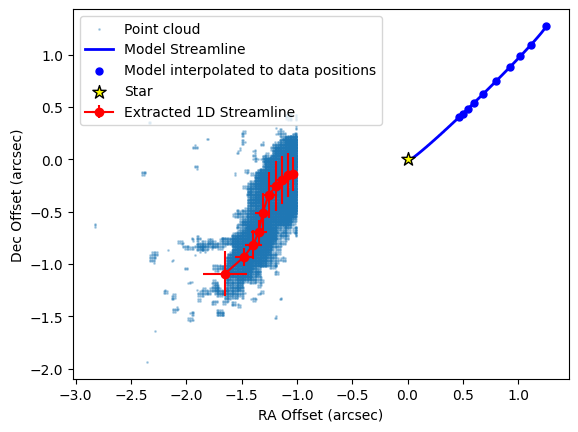

In [7]:
# forward model
ra_model, dec_model, v_model = gradient_descent.forward_model(initial_opt_params, fixed_params, distance)
# remove NaN values (due to rmin) from model
not_nan = ~jnp.isnan(ra_model) & ~jnp.isnan(dec_model) & ~jnp.isnan(v_model)
ra_model = ra_model[not_nan]
dec_model = dec_model[not_nan]
v_model = v_model[not_nan]

# Match model to data using arc-length parameterisation
ra_model_interp, dec_model_interp, v_model_interp, valid = gradient_descent.match_model_to_data_curve(
    ra_model, dec_model, v_model, ra_data, dec_data)



# mask for valid (only for arrays that haven't already been masked in matching)
v_data = v_data[valid]
ra_sigma = ra_sigma[valid]
dec_sigma = dec_sigma[valid]
v_sigma = v_sigma[valid]

# Compute chi-squared components
chi2_ra = jnp.sum(((ra_data - ra_model_interp) / ra_sigma)**2)
chi2_dec = jnp.sum(((dec_data - dec_model_interp) / dec_sigma)**2)
chi2_v = jnp.sum(((v_data - v_model_interp) / v_sigma)**2)
# Total chi-squared
chi2_total = chi2_ra + chi2_dec + chi2_v
print(f"Chi-squared RA: {chi2_ra:.2f}, Dec: {chi2_dec:.2f}, Velocity: {chi2_v:.2f}, Total: {chi2_total:.2f}")

print(ra_data)
print(ra_model_interp)

# plot it
import matplotlib.pyplot as plt
# plot the observed data points as a scatter
plt.scatter(pc_coords[0], pc_coords[1], s=1, alpha=0.3, label='Point cloud')
# plot the extracted 1D data streamline with error bars
plt.errorbar(ra_data, dec_data, xerr=ra_sigma, yerr=dec_sigma, fmt='o-', label='Extracted 1D Streamline', color='red')
# plot the model streamline
plt.plot(ra_model, dec_model, 'b-', linewidth=2, label='Model Streamline', color='blue')
# plot the model streamline interpolated to data positions
plt.scatter(ra_model_interp, dec_model_interp, s=25, label='Model interpolated to data positions', color='blue', zorder=5)
# plot the star
plt.scatter(0, 0, marker='*', s=100, color='yellow', edgecolor='black', label='Star', zorder=10)
plt.xlabel('RA Offset (arcsec)')
plt.ylabel('Dec Offset (arcsec)')
plt.legend()


In [8]:
# All the above could be done just by calling chi2_loss
chi2_total = gradient_descent.chi2_loss(initial_opt_params, fixed_params, data, uncertainties, distance)
print(chi2_total)

62841.125


### Testing one gradient descent step (the first step)

In [9]:
opt_params = initial_opt_params.copy()

# Initialize Adam moments (only for optimizable parameters)
m = {key: 0.0 for key in opt_params.keys()}
v = {key: 0.0 for key in opt_params.keys()}
# let's set learning rate and Adam parameters (I don't really know what these are)
learning_rate = 1e-2
beta1 = 0.9
beta2 = 0.999

# Create gradient function (only w.r.t. opt_params)
loss_and_grad_fn = value_and_grad(gradient_descent.chi2_loss, argnums=0)

# track loss history
loss_history = []
best_loss = float('inf')
best_opt_params = opt_params.copy()
patience_counter = 0

# let's just do one epoch to test
# Get loss and gradients
loss_value, grads = loss_and_grad_fn(opt_params, fixed_params, data, uncertainties, distance)
print(f"Initial loss: {loss_value:.2f}")
# perform one Adam update to params
opt_params, m, v = gradient_descent.adam_step(
    opt_params, grads, m, v, epoch=1, learning_rate=learning_rate, beta1=beta1, beta2=beta2
)

# track loss
loss_history.append(loss_value)

UnexpectedTracerError: Encountered an unexpected tracer. A function transformed by JAX had a side effect, allowing for a reference to an intermediate value with type float32[] wrapped in a LinearizeTracer to escape the scope of the transformation.
JAX transformations require that functions explicitly return their outputs, and disallow saving intermediate values to global state.
To catch the leak earlier, try setting the environment variable JAX_CHECK_TRACER_LEAKS or using the `jax.checking_leaks` context manager.
See https://docs.jax.dev/en/latest/errors.html#jax.errors.UnexpectedTracerError